# Notebook 3: Does a protein localize to a cellular compartment?

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../notebooks/09_bobiac_exercises/group_work_3_membrane_enrichment_solution.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/09_bobiac_exercises/group_work_3_membrane_enrichment_solution.ipynb" target="_blank">
        <img class="button-icon" src="../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

In [ ]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

## Overview

In this notebook, we will learn how to assess whether a protein localizes to a cellular compartment. In this example, the compartment is the cell membrane.

### Dataset
Our data consists of fluorescence images with five channels:
| Channel | Staining | Staining Description |
|---------|---------|----------------|
| 0 | Hoechst | Nuclear stain |
| 1 | Phalloidin | F-actin stain; whole cell marker |
| 2 | Protein A | Spot pattern |
| 3 | Protein B | Spot pattern |
| 4 | Protein C | Spot pattern |

***

## 0. Importing libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import tifffile
from bobiac_tools import overlay_labels
from scipy.spatial import KDTree

***

## 2. Load image, mask and spot table
First, we load all the data that we will need for this notebook.

In [4]:
path_image = "../../_static/images/quant/05_spatial_stats/images/F01_202.tif"
path_mask = "../../_static/images/quant/05_spatial_stats/masks/F01_202w1.TIF"
path_spots = "../../_static/images/quant/05_spatial_stats/spots/F01_202_spots.csv"


image = tifffile.imread(path_image)
mask = tifffile.imread(path_mask)
df_spots = pd.read_csv(path_spots)

mask = skimage.segmentation.clear_border(mask)

### Visually inspect the images, masks and spots
To be sure that the data we are working with is corrects, we visualise it here.

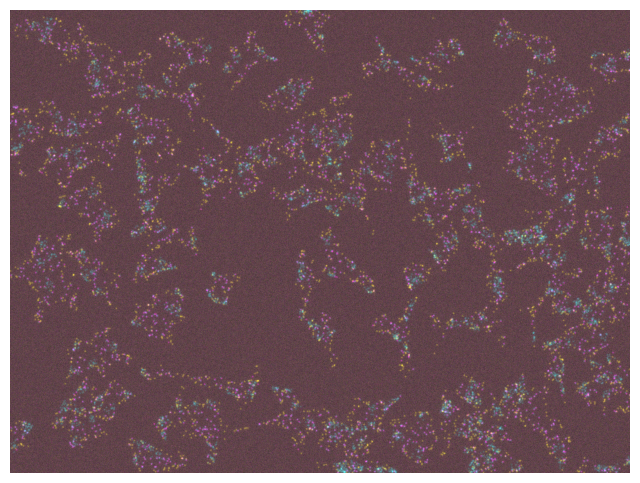

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [5]:
overlay_labels(image[2:, :, :])

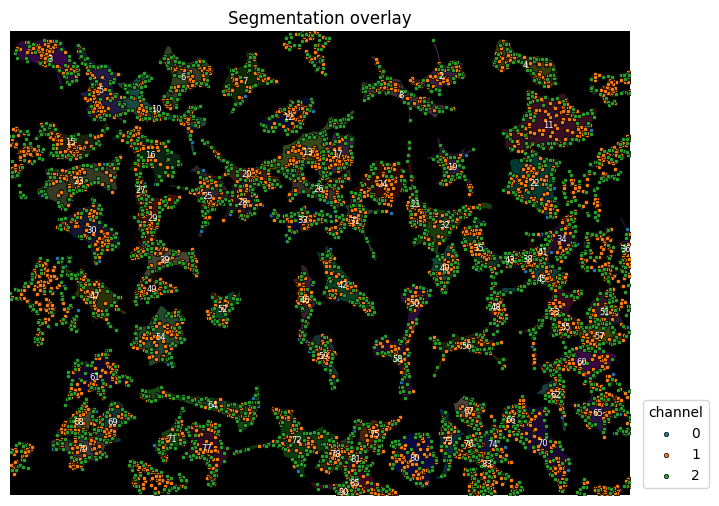

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [6]:
overlay_labels(label_mask=mask, coordinates=df_spots)

Using the `focus` attribute in `overlay` we can zoom in to view single objects.

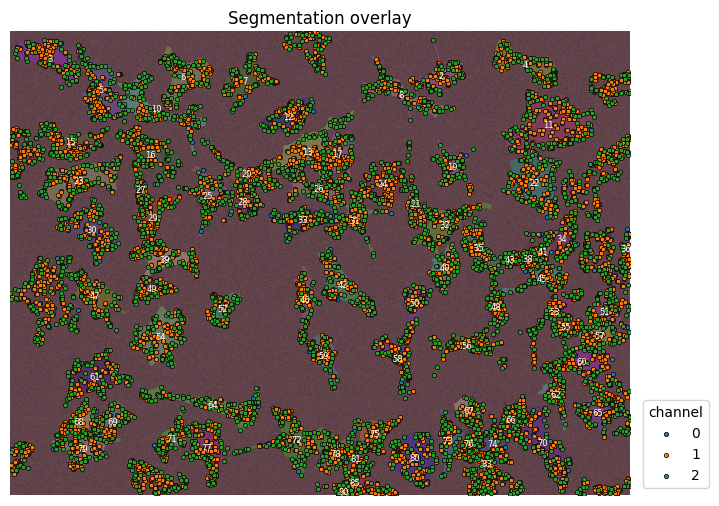

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [7]:
overlay_labels(
    image=image[2:, :, :], label_mask=mask, coordinates=df_spots, focus_object=63
)

***

## 3. Make An Analysis Plan 

### Question
**Does Protein C localize to the cell membrane?**

### Approach 
Another common task is to ask whether a distribution of objects is close to a cellular compartment; in this case the cell membrane. At first glance, this question might seem different from what we have done so far, but it is just a variation of the co-localisation analysis we have already done. The key is to transform the cell membrane region into a set of points. 

### Workflow

#### 1. Generate a reference for comparison
Randomly distributed set of points inside each cell's cytoplasm. We will call this the **random dataset**, which we will compare to our **protein datasets**.

#### 2. Measure the nearest neighbor distance
For every spot in dataset C, identify the closest spot in the cell membrane dataset and measure the distance.

#### 3. Calculate the average nearest neighbour distance
Average distance across all spots in the cell.

#### 4. Calculate the Clark-Evans Index
Calculate the ratio of the average C-membrane distance compared to the C-random distance. 
    - **Ratio = 1:** Spots in membrane dataset and the spots in the random dataset are both distributed independently of spots in dataset C
    - **Ratio < 1:** Spots in dataset C co-localise with spots in the membrane dataset
    - **Ratio > 1:** Spots in dataset C and and membrane avoid each other  

#### 5. Calculate the p-value of the Clark-Evans Index
Calculate the p-value using a comparison of multiple random patterns.



***

## 4. Assemble Datasets
As before we generate a DataFrame that stores information about cells `df_cell` and another dataframe that stores information about spots `df_spots`. We then map the cell label to each spot which allows us to count how many spots exist inside each cell.

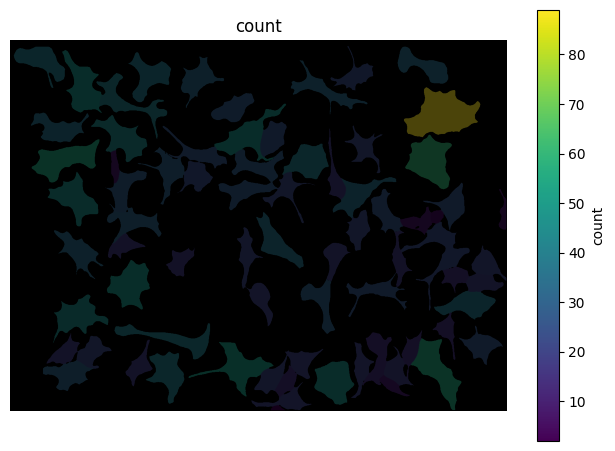

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'count'}>)

In [8]:
df_cell = pd.DataFrame(
    skimage.measure.regionprops_table(mask, properties=["area", "label"])
)

# map the cell label to the spots
df_spots["label_cell"] = mask[df_spots["y"].astype(int), df_spots["x"].astype(int)]
# delete spots in the background
df_spots = df_spots.loc[df_spots["label_cell"] != 0]
# count number of spots per cell label
mapping_spots = (
    df_spots.loc[df_spots["channel"] == 0]["label_cell"].value_counts().reset_index()
)
# add the cell count to the cell dataframe
df_cell = df_cell.merge(
    mapping_spots, left_on="label", right_on="label_cell", how="inner"
).drop(columns="label_cell")
overlay_labels(label_mask=mask, df=df_cell, id_col="label", measurement_col="count")

## 5. Perform the Colocalization Analysis

### ✍️ Exercise: Perform the analysis

Use the cross nearest neighbour analysis we developed above to find out if protein C localises preferentially to the cell membrane.

Hints: 
* The code snippet below illustrates how a boolean mask of a whole single cell can be turned into its boundary and subsequently into a list of boundary coordinates (points).
* Think carefully about which populations to randomise and compare.

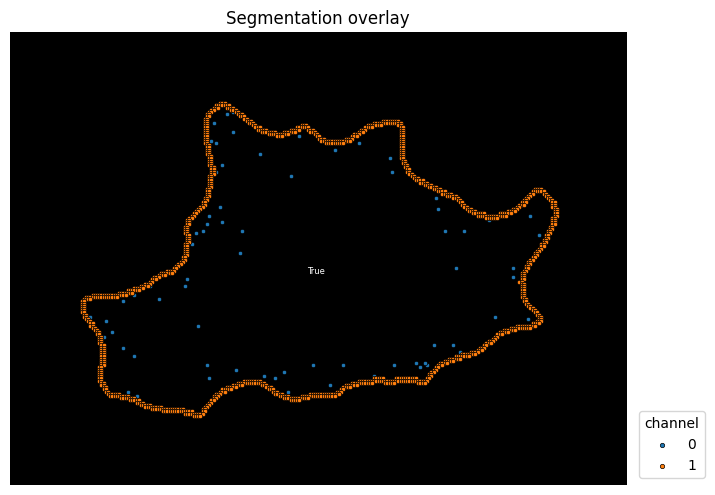

(<Figure size 800x588.571 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [9]:
from skimage.segmentation import find_boundaries

cell_id = 11

# identify the spots that belong to cell with index 11
spots_C = df_spots.loc[
    (df_spots["channel"] == 2) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()

# Identify the boundary of cell 11 and turn it into a list of coordinates (spots)
boundary = find_boundaries(
    mask == cell_id
)  # create a binary mask of just the cell boundary
coords = np.argwhere(
    boundary
)  # create a list of coordinates (y, x) for each boundary pixel

overlay_labels(label_mask=boundary, coordinates=[spots_C, coords], focus_object=True)

Here channel 0 is the observed distribution of Protein C and channel 1 are the points marking the cell membrane.

In [10]:
# or use:
# from bobiac_tools import random_points_in_mask


def random_points_in_mask(mask: np.ndarray, cell_label: int, n: int) -> np.ndarray:
    """
    Generate n random points uniformly distributed within a labeled cell region.

    Points are placed continuously using rejection sampling:
    candidate points are drawn uniformly from the bounding box of the cell and
    accepted only if they fall within the cell mask. This correctly handles
    irregular cell shapes and serves as a null model for Complete Spatial
    Randomness (CSR).

    Parameters
    ----------
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID
        and background is 0.
    cell_label : int
        ID of the cell to sample within.
    n : int
        Number of random points to generate.

    Returns
    -------
    points : (n, 2) numpy array
        Random point coordinates in (row, col) / (y, x) order.
    """
    ys, xs = np.where(mask == cell_label)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    points = []
    while len(points) < n:
        y = np.random.uniform(y_min, y_max)
        x = np.random.uniform(x_min, x_max)
        if mask[int(round(y)), int(round(x))] == cell_label:
            points.append([y, x])
    return np.array(points)

In [11]:
# or use:
# from bobiac_tools import nn_dist_target


def nn_dist_target(
    spots_from: np.ndarray,
    spots_to: np.ndarray,
    mask: np.ndarray,
    cell_id: int,
    n_repeats: int,
) -> dict[str, float]:
    """
    Calculate the nearest neighbour distance from `spots_from` to `spots_to`.
    """

    n_from = spots_from.shape[0]

    # observed NN distances
    nn_obs = KDTree(spots_to).query(spots_from, k=1)[0].mean()

    # randomised NN distances
    sims = []
    for _ in range(n_repeats):
        rnd = random_points_in_mask(mask, cell_label=cell_id, n=n_from)
        sims.append(KDTree(spots_to).query(rnd, k=1)[0].mean())

    sims = np.array(sims)

    return {
        "nn_observed": nn_obs,
        "nn_random": sims.mean(),
        "ce": nn_obs / sims.mean(),
        "pval": (sims <= nn_obs).mean(),
    }

In [12]:
n_repeats = 10

results = []
for cell_id in df_cell["label"].unique():
    boundary = find_boundaries(mask == cell_id)
    coords = np.argwhere(boundary)
    spots_C = df_spots.loc[
        (df_spots["channel"] == 2) & (df_spots["label_cell"] == cell_id)
    ][["y", "x"]].to_numpy()

    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(
        nn_dist_target(
            spots_from=spots_C,
            spots_to=coords,
            mask=mask,
            cell_id=cell_id,
            n_repeats=n_repeats,
        )
    )

df_boundary = pd.DataFrame(results)
df_boundary

,nn_observed,nn_random,ce,pval
0,4.585573,7.638058,0.600358,0.0
1,4.553575,10.318480,0.441303,0.0
2,5.152849,8.667922,0.594473,0.0
3,5.909423,10.716808,0.551416,0.0
4,5.043336,9.440907,0.534200,0.0
...,...,...,...,...
72,5.876321,14.748811,0.398427,0.0
73,5.066749,8.068001,0.628005,0.0
74,3.332884,5.160710,0.645819,0.0
75,3.951430,6.894579,0.573121,0.0


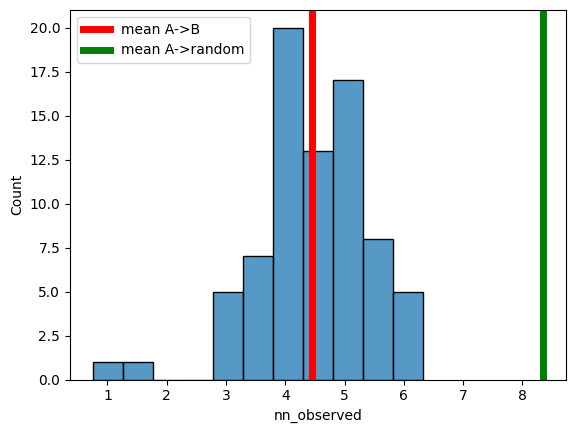

In [13]:
sns.histplot(
    df_boundary,
    x="nn_observed",
)
plt.axvline(df_boundary["nn_observed"].mean(), c="red", lw=5, label="mean A->B")
plt.axvline(df_boundary["nn_random"].mean(), c="green", lw=5, label="mean A->random")

plt.legend()

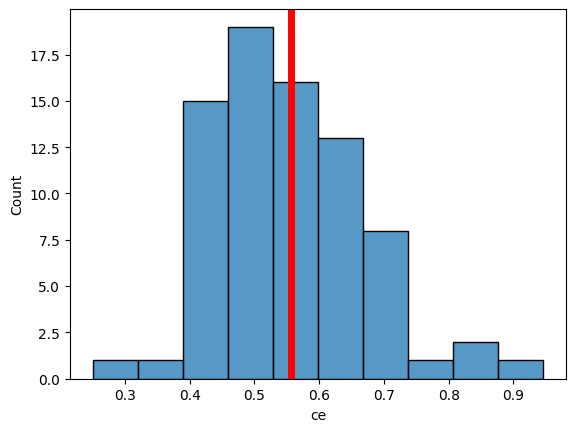

In [14]:
sns.histplot(
    df_boundary,
    x="ce",
)
plt.axvline(df_boundary["ce"].mean(), c="red", lw=5)
# plt.xlim(0,0.2)

So, definitely, Protein C localises close to the cell membrane with an average distance of ~4.5 pixels.

## Conclusion
Here we learned how to determine if a spot pattern localises to a certain area. We used similar techniques as before by turning the cell membrane into a spot pattern. Crucially, here we were only interested if our observed pattern of Protein C localized closed than random to the cell membrane. We therefore only calculated the average nearest neighbor distance from Protein C spots to the cell membrane and not the reverse direction. Moreover, we used a spatially random distribution of Protein C as the null distribution; randomising the position of the cell membrane spots would have not been useful.